# Paper 3 — Publication Figures and Manuscript Tables

This notebook generates publication figures and manuscript tables exclusively
from frozen outputs produced by the data-audit and modeling notebooks.

No models are fitted and no cohort definitions are modified here.

In [1]:
# ------------------------------------------------------------------
# 1.1
# Environment and project paths
# ------------------------------------------------------------------

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


PROJECT_DIR = Path.cwd().parent

PROCESSED_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
)

FIGURE_DIR = (
    PROJECT_DIR
    / "figures"
)

TABLE_DIR = (
    PROJECT_DIR
    / "tables"
)


FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("Project directory :", PROJECT_DIR)
print("Processed exists  :", PROCESSED_DIR.exists())
print("Figure directory  :", FIGURE_DIR)
print("Table directory   :", TABLE_DIR)

Project directory : <PROJECT_ROOT>
Processed exists  : True
Figure directory  : <PROJECT_ROOT>\figures
Table directory   : <PROJECT_ROOT>\tables


# 2. Figure 1 — Validation Design and Chemical Familiarity

The first figure summarizes the validation framework used for the large
OPV-DB benchmark.

Panel A quantifies the fraction of random-CV test observations whose
publication, donor, acceptor, or exact donor–acceptor pair is already
represented in the corresponding training fold.

Panel B summarizes the hierarchy of increasingly independent validation
regimes used to evaluate prospective generalization.

This figure establishes that random row-wise validation predominantly measures
interpolation within familiar chemical and publication domains.

In [2]:
# ------------------------------------------------------------------
# 2.1
# Load frozen OPV-DB validation assignments
# ------------------------------------------------------------------

INTERIM_DIR = (
    PROJECT_DIR
    / "data"
    / "interim"
)


opv_cv_path = (
    INTERIM_DIR
    / "FINAL_opvdb_five_regime_cv_assignments.csv"
)


opv_cv = pd.read_csv(
    opv_cv_path
)


print(
    "CV file exists:",
    opv_cv_path.exists()
)

print(
    "Dimensions:",
    opv_cv.shape
)

print(
    "Columns:"
)

print(
    opv_cv.columns.tolist()
)

CV file exists: True
Dimensions: (21590, 11)
Columns:
['id', 'doi_norm', 'donor_graph_smiles', 'acceptor_graph_smiles', 'graph_pair', 'fold_doi_held_out', 'fold_da_pair_held_out', 'fold_donor_held_out', 'fold_acceptor_held_out', 'pce', 'fold_random']


In [3]:
# ------------------------------------------------------------------
# 2.2
# Random-CV publication and chemical familiarity
# ------------------------------------------------------------------

random_overlap_rows = []


identity_columns = {
    "Publication DOI":
        "doi_norm",

    "Donor":
        "donor_graph_smiles",

    "Acceptor":
        "acceptor_graph_smiles",

    "D:A pair":
        "graph_pair",
}


for fold in [0, 1, 2]:

    train = opv_cv[
        opv_cv["fold_random"] != fold
    ]

    test = opv_cv[
        opv_cv["fold_random"] == fold
    ]


    for identity_label, column in (
        identity_columns.items()
    ):

        train_values = set(
            train[column].dropna()
        )


        seen = (
            test[column]
            .isin(train_values)
        )


        random_overlap_rows.append({

            "fold":
                fold,

            "identity":
                identity_label,

            "test_records":
                len(test),

            "seen_records":
                int(seen.sum()),

            "percent_seen":
                100 * seen.mean(),
        })


figure1_random_overlap = (
    pd.DataFrame(
        random_overlap_rows
    )
)


figure1_random_summary = (
    figure1_random_overlap
    .groupby("identity")
    .agg(
        mean_percent_seen=(
            "percent_seen",
            "mean"
        ),

        min_percent_seen=(
            "percent_seen",
            "min"
        ),

        max_percent_seen=(
            "percent_seen",
            "max"
        ),
    )
    .reset_index()
)


display(
    figure1_random_summary.round(2)
)

,identity,mean_percent_seen,min_percent_seen,max_percent_seen
0,Acceptor,95.41,94.96,95.64
1,D:A pair,82.82,82.59,83.24
2,Donor,94.20,93.34,94.82
3,Publication DOI,88.67,88.31,88.97


In [4]:
# ------------------------------------------------------------------
# 2.3
# Validation-regime hierarchy
# ------------------------------------------------------------------

validation_hierarchy = pd.DataFrame({

    "regime": [
        "Random",
        "DOI held-out",
        "D:A pair held-out",
        "Acceptor held-out",
        "Donor held-out",
    ],

    "interpretation": [
        "Familiar publications and chemistry",
        "Unseen publication",
        "Unseen donor–acceptor combination",
        "Unseen acceptor chemistry",
        "Unseen donor chemistry",
    ],

    "defining_overlap_percent": [
        np.nan,
        0,
        0,
        0,
        0,
    ],
})


display(validation_hierarchy)

,regime,interpretation,defining_overlap_percent
0,Random,Familiar publications and chemistry,NaN
1,DOI held-out,Unseen publication,0.0
2,D:A pair held-out,Unseen donor–acceptor combination,0.0
3,Acceptor held-out,Unseen acceptor chemistry,0.0
4,Donor held-out,Unseen donor chemistry,0.0


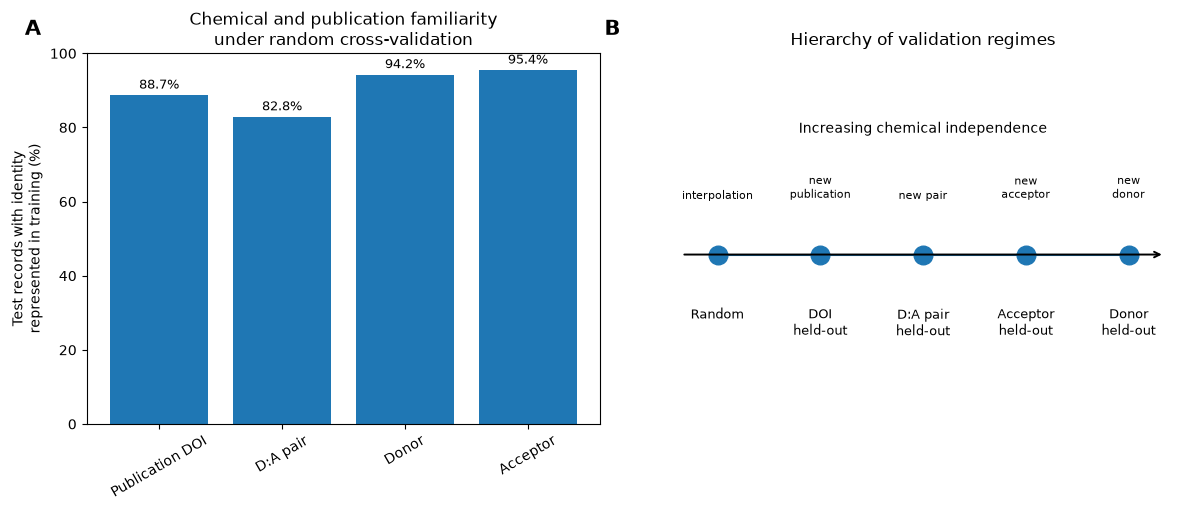

PNG saved: True
PDF saved: True


In [5]:
# ------------------------------------------------------------------
# 2.4
# Publication Figure 1 
# ------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5.2)
)


# ==============================================================
# Panel A — Random-CV familiarity
# ==============================================================

ax = axes[0]


identity_order = [
    "Publication DOI",
    "D:A pair",
    "Donor",
    "Acceptor",
]


plot_data = (
    figure1_random_summary
    .set_index("identity")
    .loc[identity_order]
    .reset_index()
)


bars = ax.bar(
    plot_data["identity"],
    plot_data["mean_percent_seen"]
)


ax.set_ylabel(
    "Test records with identity\nrepresented in training (%)"
)


ax.set_ylim(
    0,
    100
)


ax.tick_params(
    axis="x",
    rotation=30
)


for bar, value in zip(
    bars,
    plot_data["mean_percent_seen"]
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,

        value + 1.0,

        f"{value:.1f}%",

        ha="center",
        va="bottom",
        fontsize=9,
    )


ax.text(
    -0.12,
    1.05,
    "A",
    transform=ax.transAxes,
    fontsize=15,
    fontweight="bold",
)


ax.set_title(
    "Chemical and publication familiarity\nunder random cross-validation"
)


# ==============================================================
# Panel B — Validation hierarchy
# ==============================================================

ax = axes[1]


regime_labels = [
    "Random",
    "DOI\nheld-out",
    "D:A pair\nheld-out",
    "Acceptor\nheld-out",
    "Donor\nheld-out",
]


difficulty = np.arange(
    len(regime_labels)
)


ax.scatter(
    difficulty,
    np.zeros_like(difficulty),
    s=180,
    zorder=3,
)


ax.plot(
    difficulty,
    np.zeros_like(difficulty),
    linewidth=1.5,
    zorder=2,
)


for x, label in zip(
    difficulty,
    regime_labels
):

    ax.text(
        x,
        -0.10,
        label,
        ha="center",
        va="top",
        fontsize=9,
    )


annotations = [
    "interpolation",
    "new\npublication",
    "new pair",
    "new\nacceptor",
    "new\ndonor",
]


for x, annotation in zip(
    difficulty,
    annotations
):

    ax.text(
        x,
        0.10,
        annotation,
        ha="center",
        va="bottom",
        fontsize=8,
    )


ax.annotate(
    "",
    xy=(4.35, 0),
    xytext=(-0.35, 0),
    arrowprops={
        "arrowstyle": "->",
        "linewidth": 1.4,
    },
)


ax.text(
    2,
    0.23,
    "Increasing chemical independence",
    ha="center",
    fontsize=10,
)


ax.set_xlim(
    -0.5,
    4.5
)

ax.set_ylim(
    -0.32,
    0.38
)

ax.axis("off")


ax.text(
    -0.12,
    1.05,
    "B",
    transform=ax.transAxes,
    fontsize=15,
    fontweight="bold",
)


ax.set_title(
    "Hierarchy of validation regimes"
)


# ==============================================================
# Final layout and export
# ==============================================================

fig.tight_layout()


figure1_png = (
    FIGURE_DIR
    / "Figure_1_validation_framework.png"
)

figure1_pdf = (
    FIGURE_DIR
    / "Figure_1_validation_framework.pdf"
)


fig.savefig(
    figure1_png,
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    figure1_pdf,
    bbox_inches="tight"
)


plt.show()


print(
    "PNG saved:",
    figure1_png.exists()
)

print(
    "PDF saved:",
    figure1_pdf.exists()
)

# 3. Figure 2 — Predictive Generalization Across Validation Regimes

The effect of validation design on OPV structure–performance prediction is
evaluated using Ridge regression and Extra Trees applied to the same frozen
molecular representation.

Performance is reported under random, publication-held-out,
donor–acceptor-pair-held-out, acceptor-held-out, and donor-held-out
cross-validation.

Panel A reports mean R² and Panel B reports mean absolute error (MAE).
Error bars represent the standard deviation across the three frozen folds.

In [6]:
# ------------------------------------------------------------------
# 3.1
# Load OPV-DB model comparison
# ------------------------------------------------------------------

opv_model_summary_path = (
    PROCESSED_DIR
    / "opvdb_initial_model_comparison.csv"
)

opv_model_summary = pd.read_csv(
    opv_model_summary_path
)

print(
    "File exists:",
    opv_model_summary_path.exists()
)

print(
    "Dimensions:",
    opv_model_summary.shape
)

display(
    opv_model_summary.round(3)
)

File exists: True
Dimensions: (15, 8)


,model,regime,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,Dummy mean,Acceptor held-out,5.220,0.800,5.914,0.782,-0.228,0.252
1,Dummy mean,D:A pair held-out,4.957,0.359,5.683,0.303,-0.002,0.001
2,Dummy mean,DOI held-out,4.951,0.033,5.686,0.031,-0.000,0.000
3,Dummy mean,Donor held-out,5.978,1.340,6.734,1.240,-1.409,1.315
4,Dummy mean,Random,4.951,0.034,5.686,0.031,-0.000,0.000
5,Extra Trees,Acceptor held-out,2.151,0.087,2.875,0.218,0.702,0.090
6,Extra Trees,D:A pair held-out,2.043,0.080,2.742,0.076,0.765,0.033
7,Extra Trees,DOI held-out,1.934,0.030,2.670,0.054,0.779,0.007
8,Extra Trees,Donor held-out,2.800,1.124,3.390,1.045,0.362,0.510
9,Extra Trees,Random,1.740,0.017,2.456,0.036,0.813,0.004


In [7]:
# ------------------------------------------------------------------
# 3.2
# Prepare Figure 2 plotting data
# ------------------------------------------------------------------

regime_order = [
    "Random",
    "DOI held-out",
    "D:A pair held-out",
    "Acceptor held-out",
    "Donor held-out",
]

model_order = [
    "Ridge",
    "Extra Trees",
]


figure2_data = (
    opv_model_summary[
        opv_model_summary[
            "model"
        ].isin(model_order)
    ]
    .copy()
)


figure2_data["regime"] = pd.Categorical(
    figure2_data["regime"],
    categories=regime_order,
    ordered=True,
)


figure2_data = (
    figure2_data
    .sort_values(
        [
            "model",
            "regime",
        ]
    )
)


display(
    figure2_data[
        [
            "model",
            "regime",
            "R2_mean",
            "R2_std",
            "MAE_mean",
            "MAE_std",
        ]
    ].round(3)
)

,model,regime,R2_mean,R2_std,MAE_mean,MAE_std
9,Extra Trees,Random,0.813,0.004,1.740,0.017
7,Extra Trees,DOI held-out,0.779,0.007,1.934,0.030
6,Extra Trees,D:A pair held-out,0.765,0.033,2.043,0.080
5,Extra Trees,Acceptor held-out,0.702,0.090,2.151,0.087
8,Extra Trees,Donor held-out,0.362,0.510,2.800,1.124
14,Ridge,Random,0.790,0.004,1.881,0.007
12,Ridge,DOI held-out,0.727,0.008,2.160,0.025
11,Ridge,D:A pair held-out,0.725,0.037,2.221,0.147
10,Ridge,Acceptor held-out,0.550,0.242,2.636,0.296
13,Ridge,Donor held-out,-0.124,1.171,3.563,2.110


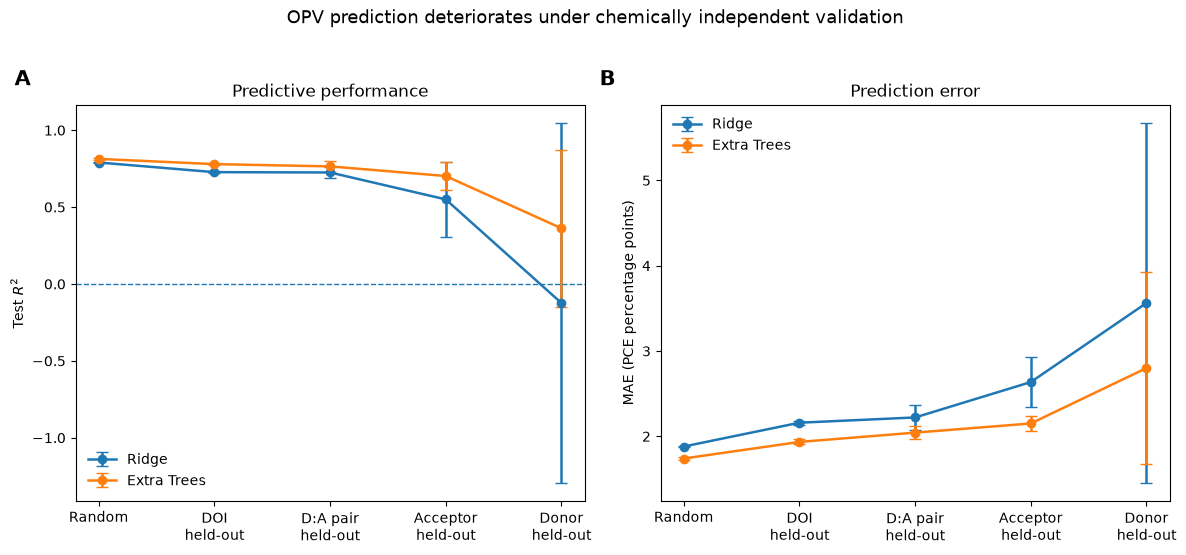

PNG saved: True
PDF saved: True


In [8]:
# ------------------------------------------------------------------
# 3.3
# Publication Figure 2
# ------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5.4)
)


x = np.arange(
    len(regime_order)
)


x_labels = [
    "Random",
    "DOI\nheld-out",
    "D:A pair\nheld-out",
    "Acceptor\nheld-out",
    "Donor\nheld-out",
]


# ==============================================================
# Panel A — R²
# ==============================================================

ax = axes[0]


for model_name in model_order:

    subset = (
        figure2_data[
            figure2_data[
                "model"
            ] == model_name
        ]
        .set_index("regime")
        .reindex(regime_order)
    )


    ax.errorbar(
        x,
        subset["R2_mean"],
        yerr=subset["R2_std"],
        marker="o",
        markersize=6,
        linewidth=1.8,
        capsize=4,
        label=model_name,
    )


ax.axhline(
    0,
    linewidth=1,
    linestyle="--"
)


ax.set_xticks(x)

ax.set_xticklabels(
    x_labels
)

ax.set_ylabel(
    r"Test $R^2$"
)

ax.set_title(
    "Predictive performance"
)

ax.legend(
    frameon=False
)


ax.text(
    -0.12,
    1.05,
    "A",
    transform=ax.transAxes,
    fontsize=15,
    fontweight="bold",
)


# ==============================================================
# Panel B — MAE
# ==============================================================

ax = axes[1]


for model_name in model_order:

    subset = (
        figure2_data[
            figure2_data[
                "model"
            ] == model_name
        ]
        .set_index("regime")
        .reindex(regime_order)
    )


    ax.errorbar(
        x,
        subset["MAE_mean"],
        yerr=subset["MAE_std"],
        marker="o",
        markersize=6,
        linewidth=1.8,
        capsize=4,
        label=model_name,
    )


ax.set_xticks(x)

ax.set_xticklabels(
    x_labels
)

ax.set_ylabel(
    "MAE (PCE percentage points)"
)

ax.set_title(
    "Prediction error"
)

ax.legend(
    frameon=False
)


ax.text(
    -0.12,
    1.05,
    "B",
    transform=ax.transAxes,
    fontsize=15,
    fontweight="bold",
)


# ==============================================================
# Final layout
# ==============================================================

fig.suptitle(
    "OPV prediction deteriorates under chemically independent validation",
    fontsize=13,
    y=1.02,
)


fig.tight_layout()


figure2_png = (
    FIGURE_DIR
    / "Figure_2_OPV_generalization_performance.png"
)

figure2_pdf = (
    FIGURE_DIR
    / "Figure_2_OPV_generalization_performance.pdf"
)


fig.savefig(
    figure2_png,
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    figure2_pdf,
    bbox_inches="tight"
)


plt.show()


print(
    "PNG saved:",
    figure2_png.exists()
)

print(
    "PDF saved:",
    figure2_pdf.exists()
)

# 4. Figure 3 — Structure and Processing Contributions

The predictive contributions of molecular structure and processing
information are compared using the frozen Wen–Zhang–Ma benchmark.

Three Extra Trees models use processing-only, structure-only, or combined
structure–processing representations under identical validation folds.

Panel A reports predictive R² across validation regimes. Panel B reports the
percentage reduction in MAE obtained by adding processing information to the
structure-only representation.

In [9]:
# ------------------------------------------------------------------
# 4.1
# Load Wen/Ma structure-processing results
# ------------------------------------------------------------------

wen_summary_path = (
    PROCESSED_DIR
    / "wen_structure_processing_summary.csv"
)

processing_value_path = (
    PROCESSED_DIR
    / "wen_processing_incremental_value.csv"
)


wen_summary = pd.read_csv(
    wen_summary_path
)

processing_value_fig = pd.read_csv(
    processing_value_path
)


print(
    "Summary exists:",
    wen_summary_path.exists()
)

print(
    "Processing-value file exists:",
    processing_value_path.exists()
)


display(
    wen_summary.round(3)
)

display(
    processing_value_fig.round(3)
)

Summary exists: True
Processing-value file exists: True


,feature_panel,regime,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,Processing only,Acceptor held-out,2.580,0.428,3.361,0.579,0.439,0.142
1,Processing only,D:A pair held-out,2.745,0.351,3.506,0.463,0.364,0.287
2,Processing only,Donor held-out,3.134,0.077,3.954,0.020,0.100,0.165
3,Processing only,Random,1.788,0.066,2.491,0.232,0.698,0.066
4,Structure + processing,Acceptor held-out,2.570,0.197,3.336,0.416,0.451,0.072
5,Structure + processing,D:A pair held-out,2.585,0.300,3.379,0.420,0.445,0.037
6,Structure + processing,Donor held-out,3.157,0.210,3.890,0.342,0.118,0.244
7,Structure + processing,Random,1.027,0.099,1.679,0.218,0.862,0.039
8,Structure only,Acceptor held-out,2.633,0.117,3.419,0.330,0.422,0.052
9,Structure only,D:A pair held-out,2.611,0.428,3.403,0.546,0.439,0.057


,regime,structure_MAE,structure_RMSE,structure_R2,full_MAE,full_RMSE,full_R2,MAE_reduction_from_processing,MAE_percent_reduction,R2_gain_from_processing
0,Acceptor held-out,2.633,3.419,0.422,2.570,3.336,0.451,0.063,2.386,0.028
1,D:A pair held-out,2.611,3.403,0.439,2.585,3.379,0.445,0.026,1.014,0.005
2,Donor held-out,3.188,3.930,0.097,3.157,3.890,0.118,0.031,0.966,0.021
3,Random,1.277,1.974,0.810,1.027,1.679,0.862,0.249,19.523,0.051


In [10]:
# ------------------------------------------------------------------
# 4.2
# Prepare plotting data
# ------------------------------------------------------------------

wen_regime_order = [
    "Random",
    "D:A pair held-out",
    "Acceptor held-out",
    "Donor held-out",
]


feature_panel_order = [
    "Processing only",
    "Structure only",
    "Structure + processing",
]


figure3_data = (
    wen_summary.copy()
)


figure3_data["regime"] = pd.Categorical(
    figure3_data["regime"],
    categories=wen_regime_order,
    ordered=True,
)


figure3_data["feature_panel"] = pd.Categorical(
    figure3_data["feature_panel"],
    categories=feature_panel_order,
    ordered=True,
)


figure3_data = (
    figure3_data
    .sort_values(
        [
            "feature_panel",
            "regime",
        ]
    )
)


processing_value_fig["regime"] = pd.Categorical(
    processing_value_fig["regime"],
    categories=wen_regime_order,
    ordered=True,
)


processing_value_fig = (
    processing_value_fig
    .sort_values("regime")
)


display(
    figure3_data[
        [
            "feature_panel",
            "regime",
            "R2_mean",
            "R2_std",
            "MAE_mean",
        ]
    ].round(3)
)

,feature_panel,regime,R2_mean,R2_std,MAE_mean
3,Processing only,Random,0.698,0.066,1.788
1,Processing only,D:A pair held-out,0.364,0.287,2.745
0,Processing only,Acceptor held-out,0.439,0.142,2.580
2,Processing only,Donor held-out,0.100,0.165,3.134
11,Structure only,Random,0.810,0.039,1.277
9,Structure only,D:A pair held-out,0.439,0.057,2.611
8,Structure only,Acceptor held-out,0.422,0.052,2.633
10,Structure only,Donor held-out,0.097,0.259,3.188
7,Structure + processing,Random,0.862,0.039,1.027
5,Structure + processing,D:A pair held-out,0.445,0.037,2.585


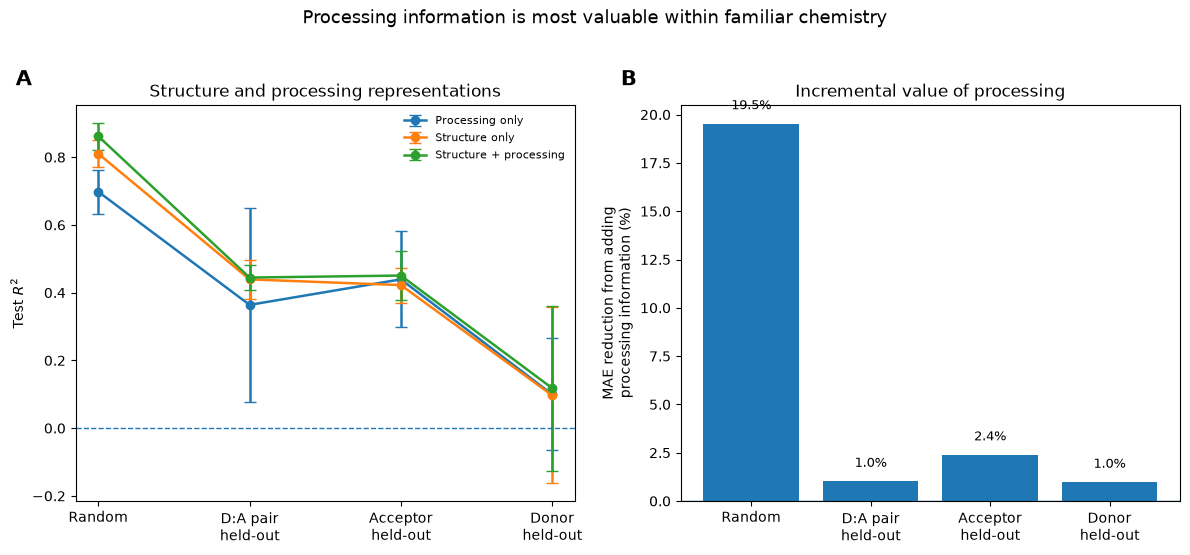

PNG saved: True
PDF saved: True


In [11]:
# ------------------------------------------------------------------
# 4.3
# Publication Figure 3
# ------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5.4)
)


x = np.arange(
    len(wen_regime_order)
)


x_labels = [
    "Random",
    "D:A pair\nheld-out",
    "Acceptor\nheld-out",
    "Donor\nheld-out",
]


# ==============================================================
# Panel A — R² by feature representation
# ==============================================================

ax = axes[0]


for panel_name in feature_panel_order:

    subset = (
        figure3_data[
            figure3_data[
                "feature_panel"
            ] == panel_name
        ]
        .set_index("regime")
        .reindex(wen_regime_order)
    )


    ax.errorbar(
        x,
        subset["R2_mean"],
        yerr=subset["R2_std"],
        marker="o",
        markersize=6,
        linewidth=1.8,
        capsize=4,
        label=panel_name,
    )


ax.axhline(
    0,
    linestyle="--",
    linewidth=1,
)


ax.set_xticks(x)

ax.set_xticklabels(
    x_labels
)


ax.set_ylabel(
    r"Test $R^2$"
)


ax.set_title(
    "Structure and processing representations"
)


ax.legend(
    frameon=False,
    fontsize=8,
)


ax.text(
    -0.12,
    1.05,
    "A",
    transform=ax.transAxes,
    fontsize=15,
    fontweight="bold",
)


# ==============================================================
# Panel B — Incremental processing benefit
# ==============================================================

ax = axes[1]


bars = ax.bar(
    x,
    processing_value_fig[
        "MAE_percent_reduction"
    ],
)


ax.axhline(
    0,
    linewidth=1,
)


ax.set_xticks(x)

ax.set_xticklabels(
    x_labels
)


ax.set_ylabel(
    "MAE reduction from adding\nprocessing information (%)"
)


ax.set_title(
    "Incremental value of processing"
)


for bar, value in zip(
    bars,
    processing_value_fig[
        "MAE_percent_reduction"
    ],
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,

        value + 0.6,

        f"{value:.1f}%",

        ha="center",
        va="bottom",
        fontsize=9,
    )


ax.text(
    -0.12,
    1.05,
    "B",
    transform=ax.transAxes,
    fontsize=15,
    fontweight="bold",
)


# ==============================================================
# Final layout
# ==============================================================

fig.suptitle(
    "Processing information is most valuable within familiar chemistry",
    fontsize=13,
    y=1.02,
)


fig.tight_layout()


figure3_png = (
    FIGURE_DIR
    / "Figure_3_structure_processing_contributions.png"
)

figure3_pdf = (
    FIGURE_DIR
    / "Figure_3_structure_processing_contributions.pdf"
)


fig.savefig(
    figure3_png,
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    figure3_pdf,
    bbox_inches="tight"
)


plt.show()


print(
    "PNG saved:",
    figure3_png.exists()
)

print(
    "PDF saved:",
    figure3_pdf.exists()
)

# 5. Figure 4 — Processing Benefit Depends on Chemical Familiarity

The large processing advantage observed under random validation is examined
according to whether the donor–acceptor material system is already represented
in training.

Panel A compares the MAE reduction obtained from adding processing information
for unseen versus familiar D:A systems.

Panel B resolves the same effect according to the number of same-system
training observations available to the model.

The analysis tests whether processing descriptors primarily support
condition-level refinement within familiar chemistry rather than extrapolation
toward completely unseen material systems.

In [12]:
# ------------------------------------------------------------------
# 5.1
# Load familiar-vs-unseen processing results
# ------------------------------------------------------------------

seen_unseen_path = (
    PROCESSED_DIR
    / "wen_processing_value_seen_vs_unseen_pairs.csv"
)

support_path = (
    PROCESSED_DIR
    / "wen_processing_value_by_pair_support.csv"
)

bootstrap_path = (
    PROCESSED_DIR
    / "wen_unique_pair_bootstrap_processing_benefit.csv"
)


seen_unseen_fig = pd.read_csv(
    seen_unseen_path
)

support_fig = pd.read_csv(
    support_path
)

bootstrap_fig = pd.read_csv(
    bootstrap_path
)


print(
    "Seen/unseen file:",
    seen_unseen_path.exists()
)

print(
    "Support file:",
    support_path.exists()
)

print(
    "Bootstrap file:",
    bootstrap_path.exists()
)


display(
    seen_unseen_fig.round(3)
)

display(
    support_fig.round(3)
)

display(
    bootstrap_fig.round(4)
)

Seen/unseen file: True
Support file: True
Bootstrap file: True


,pair_seen_in_training,records,structure_MAE,full_MAE,mean_error_reduction,median_error_reduction,MAE_percent_reduction
0,False,146,2.596,2.548,0.047,0.029,1.824
1,True,848,1.049,0.765,0.284,0.103,27.060


,pair_support_bin,records,unique_pairs,structure_MAE,full_MAE,mean_error_reduction,median_error_reduction,MAE_percent_reduction
0,0,146,134,2.596,2.548,0.047,0.029,1.824
1,1–2,127,41,1.161,1.082,0.079,0.029,6.847
2,3–5,280,59,1.190,0.821,0.369,0.091,30.983
3,6–10,395,59,0.954,0.643,0.311,0.148,32.602
4,>10,46,10,0.705,0.605,0.101,0.078,14.282


,quantity,value
0,seen-system mean error reduction,0.2839
1,unseen-system mean error reduction,0.0473
2,seen minus unseen,0.2366
3,95% CI lower,0.0854
4,95% CI upper,0.3991
5,successful bootstrap replicates,10000.0000


In [13]:
# ------------------------------------------------------------------
# 5.2
# Prepare Figure 4 data — robust version
# ------------------------------------------------------------------

# --------------------------------------------------------------
# Normalize pair_seen_in_training regardless of CSV dtype
# --------------------------------------------------------------

def normalize_boolean(value):

    text = str(value).strip().lower()

    if text in {
        "true",
        "1",
        "1.0",
        "yes"
    }:
        return True

    if text in {
        "false",
        "0",
        "0.0",
        "no"
    }:
        return False

    return np.nan


seen_unseen_fig[
    "pair_seen_in_training"
] = (
    seen_unseen_fig[
        "pair_seen_in_training"
    ]
    .apply(normalize_boolean)
)


print(
    "Normalized familiarity values:"
)

print(
    seen_unseen_fig[
        "pair_seen_in_training"
    ].value_counts(
        dropna=False
    )
)


# --------------------------------------------------------------
# Panel A ordering
# --------------------------------------------------------------

familiarity_order = [
    False,
    True,
]

familiarity_labels = [
    "Unseen\nD:A pair",
    "Familiar\nD:A pair",
]


seen_unseen_plot = (
    seen_unseen_fig
    .set_index(
        "pair_seen_in_training"
    )
    .reindex(
        familiarity_order
    )
    .reset_index()
)


# --------------------------------------------------------------
# Panel B ordering
# --------------------------------------------------------------

support_order = [
    "0",
    "1–2",
    "3–5",
    "6–10",
    ">10",
]


support_fig[
    "pair_support_bin"
] = (
    support_fig[
        "pair_support_bin"
    ]
    .astype(str)
    .str.strip()
)


support_fig[
    "pair_support_bin"
] = pd.Categorical(
    support_fig[
        "pair_support_bin"
    ],
    categories=support_order,
    ordered=True,
)


support_plot = (
    support_fig
    .sort_values(
        "pair_support_bin"
    )
)


# --------------------------------------------------------------
# Verification
# --------------------------------------------------------------

print(
    "\nPanel A rows:",
    len(seen_unseen_plot)
)

display(
    seen_unseen_plot[
        [
            "pair_seen_in_training",
            "records",
            "MAE_percent_reduction",
        ]
    ].round(3)
)


print(
    "\nPanel B rows:",
    len(support_plot)
)

display(
    support_plot[
        [
            "pair_support_bin",
            "records",
            "unique_pairs",
            "MAE_percent_reduction",
        ]
    ].round(3)
)

Normalized familiarity values:
pair_seen_in_training
False    1
True     1
Name: count, dtype: int64

Panel A rows: 2


,pair_seen_in_training,records,MAE_percent_reduction
0,False,146,1.824
1,True,848,27.060



Panel B rows: 5


,pair_support_bin,records,unique_pairs,MAE_percent_reduction
0,0,146,134,1.824
1,1–2,127,41,6.847
2,3–5,280,59,30.983
3,6–10,395,59,32.602
4,>10,46,10,14.282


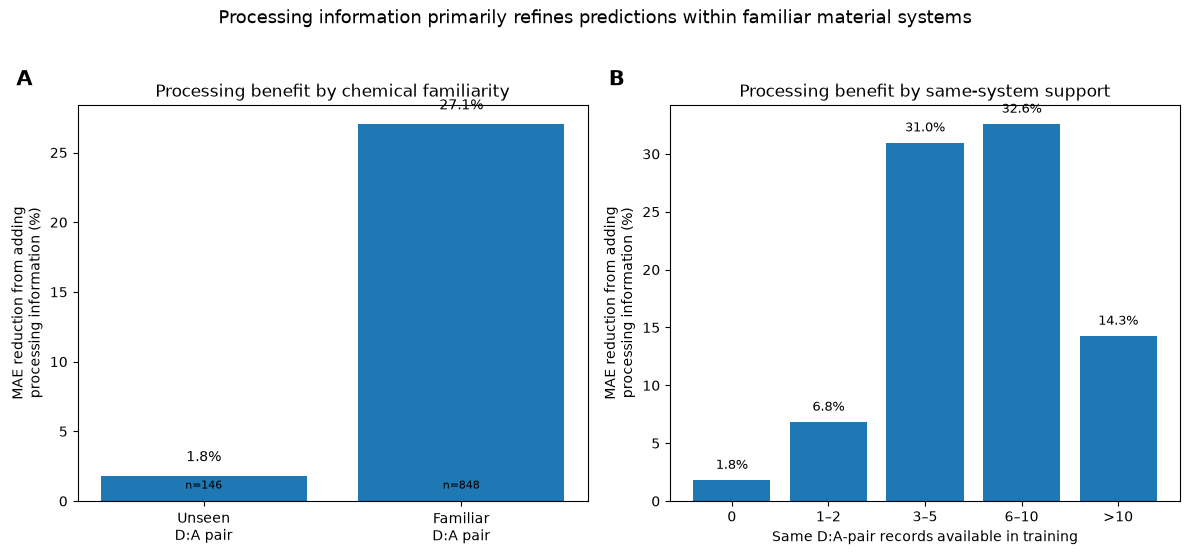

PNG saved: True
PDF saved: True


In [14]:
# ------------------------------------------------------------------
# 5.3
# Publication Figure 4
# ------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5.4)
)


# ==============================================================
# Panel A — Familiar versus unseen chemistry
# ==============================================================

ax = axes[0]


x_a = np.arange(
    len(seen_unseen_plot)
)


bars = ax.bar(
    x_a,
    seen_unseen_plot[
        "MAE_percent_reduction"
    ],
)


ax.set_xticks(
    x_a
)

ax.set_xticklabels(
    familiarity_labels
)


ax.set_ylabel(
    "MAE reduction from adding\nprocessing information (%)"
)


ax.set_title(
    "Processing benefit by chemical familiarity"
)


for bar, value, records in zip(
    bars,
    seen_unseen_plot[
        "MAE_percent_reduction"
    ],
    seen_unseen_plot[
        "records"
    ],
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,

        value + 0.8,

        f"{value:.1f}%",

        ha="center",
        va="bottom",
        fontsize=10,
    )

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,

        0.7,

        f"n={int(records)}",

        ha="center",
        va="bottom",
        fontsize=8,
    )


ax.text(
    -0.12,
    1.05,
    "A",
    transform=ax.transAxes,
    fontsize=15,
    fontweight="bold",
)


# ==============================================================
# Panel B — Benefit by same-pair training support
# ==============================================================

ax = axes[1]


x_b = np.arange(
    len(support_plot)
)


bars = ax.bar(
    x_b,
    support_plot[
        "MAE_percent_reduction"
    ],
)


ax.set_xticks(
    x_b
)

ax.set_xticklabels(
    support_order
)


ax.set_xlabel(
    "Same D:A-pair records available in training"
)


ax.set_ylabel(
    "MAE reduction from adding\nprocessing information (%)"
)


ax.set_title(
    "Processing benefit by same-system support"
)


for bar, value in zip(
    bars,
    support_plot[
        "MAE_percent_reduction"
    ],
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,

        value + 0.7,

        f"{value:.1f}%",

        ha="center",
        va="bottom",
        fontsize=9,
    )


ax.text(
    -0.12,
    1.05,
    "B",
    transform=ax.transAxes,
    fontsize=15,
    fontweight="bold",
)


# ==============================================================
# Final layout
# ==============================================================

fig.suptitle(
    "Processing information primarily refines predictions within familiar material systems",
    fontsize=13,
    y=1.02,
)


fig.tight_layout()


figure4_png = (
    FIGURE_DIR
    / "Figure_4_processing_familiarity_effect.png"
)

figure4_pdf = (
    FIGURE_DIR
    / "Figure_4_processing_familiarity_effect.pdf"
)


fig.savefig(
    figure4_png,
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    figure4_pdf,
    bbox_inches="tight"
)


plt.show()


print(
    "PNG saved:",
    figure4_png.exists()
)

print(
    "PDF saved:",
    figure4_pdf.exists()
)

# 6. Figure 5 — Uncertainty Reliability Under Chemical Domain Shift

The reliability of Extra Trees ensemble dispersion as an uncertainty indicator
is evaluated across the frozen validation regimes.

Panel A reports the Spearman association between ensemble standard deviation
and absolute prediction error.

Panel B reports the fraction of the largest 20% of prediction errors captured
within the 20% most uncertain predictions. A random uncertainty ranking would
capture approximately 20%.

The analysis tests whether a model that becomes less accurate under chemical
domain shift also retains the ability to identify its own unreliable
predictions.

In [15]:
# ------------------------------------------------------------------
# 6.1
# Load uncertainty-screening outputs
# ------------------------------------------------------------------

uncertainty_association_path = (
    PROCESSED_DIR
    / "wen_uncertainty_error_association.csv"
)

uncertainty_capture_path = (
    PROCESSED_DIR
    / "wen_uncertainty_error_capture.csv"
)


uncertainty_assoc_fig = pd.read_csv(
    uncertainty_association_path
)

uncertainty_capture_fig = pd.read_csv(
    uncertainty_capture_path
)


print(
    "Association file exists:",
    uncertainty_association_path.exists()
)

print(
    "Capture file exists:",
    uncertainty_capture_path.exists()
)


display(
    uncertainty_assoc_fig.round(4)
)

display(
    uncertainty_capture_fig.round(2)
)

Association file exists: True
Capture file exists: True


,regime,records,mean_uncertainty,mean_absolute_error,pearson_r,pearson_p,spearman_rho,spearman_p
0,Random,994,0.8943,1.0272,0.6026,0.0000,0.4616,0.0000
1,D:A pair held-out,994,2.6471,2.5845,0.2403,0.0000,0.2766,0.0000
2,Donor held-out,994,3.0306,3.1571,-0.0190,0.5493,0.0466,0.1422
3,Acceptor held-out,994,2.6097,2.5700,0.2679,0.0000,0.2462,0.0000


,regime,top_fraction,top_error_records,captured_by_high_uncertainty,capture_percent,random_expected_percent
0,Random,0.2,199,112,56.28,20.0
1,D:A pair held-out,0.2,199,71,35.68,20.0
2,Donor held-out,0.2,199,32,16.08,20.0
3,Acceptor held-out,0.2,199,55,27.64,20.0


In [16]:
# ------------------------------------------------------------------
# 6.2
# Prepare uncertainty plotting data
# ------------------------------------------------------------------

uncertainty_regime_order = [
    "Random",
    "D:A pair held-out",
    "Acceptor held-out",
    "Donor held-out",
]


uncertainty_assoc_fig["regime"] = pd.Categorical(
    uncertainty_assoc_fig["regime"],
    categories=uncertainty_regime_order,
    ordered=True,
)

uncertainty_capture_fig["regime"] = pd.Categorical(
    uncertainty_capture_fig["regime"],
    categories=uncertainty_regime_order,
    ordered=True,
)


uncertainty_assoc_plot = (
    uncertainty_assoc_fig
    .sort_values("regime")
)

uncertainty_capture_plot = (
    uncertainty_capture_fig
    .sort_values("regime")
)


display(
    uncertainty_assoc_plot[
        [
            "regime",
            "spearman_rho",
            "spearman_p",
        ]
    ].round(4)
)


display(
    uncertainty_capture_plot[
        [
            "regime",
            "capture_percent",
            "random_expected_percent",
        ]
    ].round(2)
)

,regime,spearman_rho,spearman_p
0,Random,0.4616,0.0000
1,D:A pair held-out,0.2766,0.0000
3,Acceptor held-out,0.2462,0.0000
2,Donor held-out,0.0466,0.1422


,regime,capture_percent,random_expected_percent
0,Random,56.28,20.0
1,D:A pair held-out,35.68,20.0
3,Acceptor held-out,27.64,20.0
2,Donor held-out,16.08,20.0


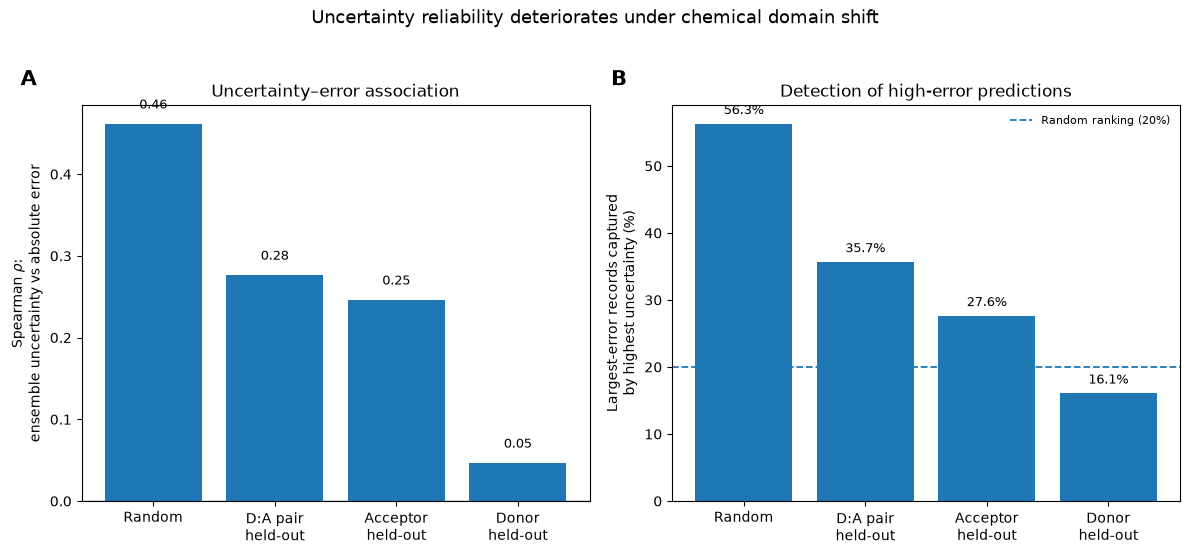

PNG saved: True
PDF saved: True


In [17]:
# ------------------------------------------------------------------
# 6.3
# Publication Figure 5
# ------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5.4)
)


x = np.arange(
    len(uncertainty_regime_order)
)


x_labels = [
    "Random",
    "D:A pair\nheld-out",
    "Acceptor\nheld-out",
    "Donor\nheld-out",
]


# ==============================================================
# Panel A — uncertainty/error association
# ==============================================================

ax = axes[0]


bars = ax.bar(
    x,
    uncertainty_assoc_plot[
        "spearman_rho"
    ],
)


ax.axhline(
    0,
    linewidth=1,
)


ax.set_xticks(x)

ax.set_xticklabels(
    x_labels
)


ax.set_ylabel(
    r"Spearman $\rho$:"
    "\nensemble uncertainty vs absolute error"
)


ax.set_title(
    "Uncertainty–error association"
)


for bar, value in zip(
    bars,
    uncertainty_assoc_plot[
        "spearman_rho"
    ],
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,

        value + 0.015,

        f"{value:.2f}",

        ha="center",
        va="bottom",
        fontsize=9,
    )


ax.text(
    -0.12,
    1.05,
    "A",
    transform=ax.transAxes,
    fontsize=15,
    fontweight="bold",
)


# ==============================================================
# Panel B — capture of large errors
# ==============================================================

ax = axes[1]


bars = ax.bar(
    x,
    uncertainty_capture_plot[
        "capture_percent"
    ],
)


ax.axhline(
    20,
    linestyle="--",
    linewidth=1.3,
    label="Random ranking (20%)",
)


ax.set_xticks(x)

ax.set_xticklabels(
    x_labels
)


ax.set_ylabel(
    "Largest-error records captured\nby highest uncertainty (%)"
)


ax.set_title(
    "Detection of high-error predictions"
)


for bar, value in zip(
    bars,
    uncertainty_capture_plot[
        "capture_percent"
    ],
):

    ax.text(
        bar.get_x()
        + bar.get_width() / 2,

        value + 1.0,

        f"{value:.1f}%",

        ha="center",
        va="bottom",
        fontsize=9,
    )


ax.legend(
    frameon=False,
    fontsize=8,
)


ax.text(
    -0.12,
    1.05,
    "B",
    transform=ax.transAxes,
    fontsize=15,
    fontweight="bold",
)


# ==============================================================
# Final layout
# ==============================================================

fig.suptitle(
    "Uncertainty reliability deteriorates under chemical domain shift",
    fontsize=13,
    y=1.02,
)


fig.tight_layout()


figure5_png = (
    FIGURE_DIR
    / "Figure_5_uncertainty_domain_shift.png"
)

figure5_pdf = (
    FIGURE_DIR
    / "Figure_5_uncertainty_domain_shift.pdf"
)


fig.savefig(
    figure5_png,
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    figure5_pdf,
    bbox_inches="tight"
)


plt.show()


print(
    "PNG saved:",
    figure5_png.exists()
)

print(
    "PDF saved:",
    figure5_pdf.exists()
)

# 7. Figure 6 — Processing Drivers Across Chemical Domains

Grouped permutation importance is used to identify which physical processing
factors contribute to prediction under different validation regimes.

Importance is expressed as the increase in held-out MAE after jointly
permuting all variables belonging to a physical processing factor.

The comparison distinguishes processing information that is primarily useful
for condition-level refinement within familiar chemistry from processing
information that retains predictive value across chemical domains.

In [18]:
# ------------------------------------------------------------------
# 7.1
# Load grouped processing importance
# ------------------------------------------------------------------

importance_path = (
    PROCESSED_DIR
    / "wen_grouped_processing_importance_summary.csv"
)


importance_fig = pd.read_csv(
    importance_path
)


print(
    "Importance file exists:",
    importance_path.exists()
)

print(
    "Dimensions:",
    importance_fig.shape
)


display(
    importance_fig.round(4)
)

Importance file exists: True
Dimensions: (28, 8)


,regime,processing_group,mean_MAE_increase,std_MAE_increase,median_MAE_increase,mean_MAE_percent_increase,positive_fraction,importance_rank
0,Acceptor held-out,Active-layer thickness,-0.0007,0.0009,-0.0008,-0.0284,0.2333,6.0
1,Acceptor held-out,Additive protocol,0.0455,0.0349,0.0531,1.7995,0.8333,2.0
2,Acceptor held-out,Annealing protocol,0.0502,0.0235,0.0504,1.9551,1.0000,1.0
3,Acceptor held-out,Blend concentration,-0.0010,0.0040,-0.0024,-0.0472,0.3333,7.0
4,Acceptor held-out,D:A ratio,0.0005,0.0035,-0.0002,0.0248,0.5000,5.0
5,Acceptor held-out,Solvent chemistry,0.0145,0.0313,0.0280,0.4997,0.6333,3.0
6,Acceptor held-out,Spin coating,0.0075,0.0047,0.0079,0.2890,1.0000,4.0
7,D:A pair held-out,Active-layer thickness,0.0006,0.0012,0.0005,0.0252,0.6000,5.0
8,D:A pair held-out,Additive protocol,0.0207,0.0462,0.0053,0.6624,0.6000,3.0
9,D:A pair held-out,Annealing protocol,0.0648,0.0231,0.0648,2.5613,1.0000,2.0


In [19]:
# ------------------------------------------------------------------
# 7.2
# Prepare Figure 6 data
# ------------------------------------------------------------------

processing_order = [
    "Annealing protocol",
    "Additive protocol",
    "Solvent chemistry",
    "Blend concentration",
    "D:A ratio",
    "Spin coating",
    "Active-layer thickness",
]


importance_regime_order = [
    "Random",
    "D:A pair held-out",
    "Acceptor held-out",
    "Donor held-out",
]


importance_matrix = (
    importance_fig
    .pivot(
        index="processing_group",
        columns="regime",
        values="mean_MAE_percent_increase"
    )
    .reindex(
        index=processing_order,
        columns=importance_regime_order,
    )
)


display(
    importance_matrix.round(2)
)

regime,Random,D:A pair held-out,Acceptor held-out,Donor held-out
processing_group,,,,
Annealing protocol,19.14,2.56,1.96,1.73
Additive protocol,13.52,0.66,1.80,0.41
Solvent chemistry,6.40,3.60,0.50,1.88
Blend concentration,0.60,0.08,-0.05,-0.01
D:A ratio,0.53,-0.06,0.02,-0.02
Spin coating,0.53,-0.08,0.29,0.05
Active-layer thickness,0.21,0.03,-0.03,-0.01


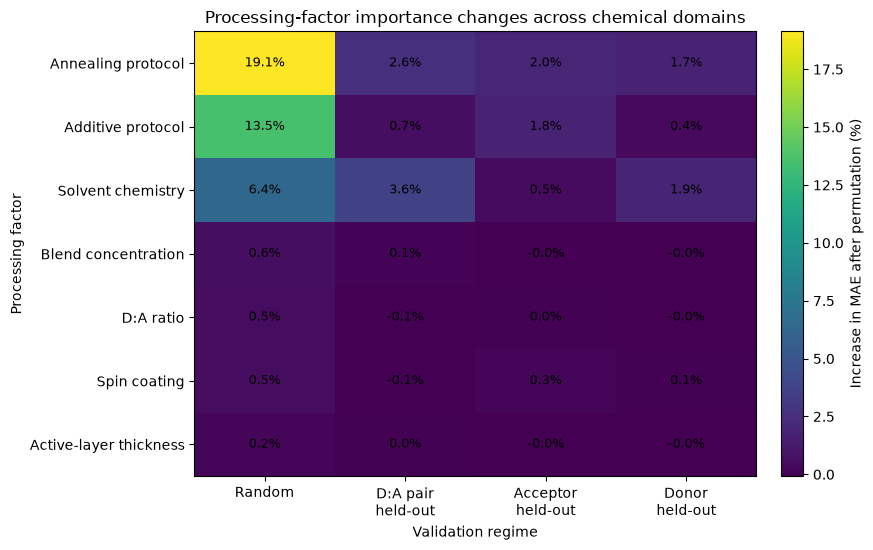

PNG saved: True
PDF saved: True


In [20]:
# ------------------------------------------------------------------
# 7.3
# Publication Figure 6
# ------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8.8, 5.6)
)


matrix_values = (
    importance_matrix
    .to_numpy(dtype=float)
)


image = ax.imshow(
    matrix_values,
    aspect="auto"
)


ax.set_xticks(
    np.arange(
        len(
            importance_regime_order
        )
    )
)

ax.set_xticklabels(
    [
        "Random",
        "D:A pair\nheld-out",
        "Acceptor\nheld-out",
        "Donor\nheld-out",
    ]
)


ax.set_yticks(
    np.arange(
        len(processing_order)
    )
)

ax.set_yticklabels(
    processing_order
)


# --------------------------------------------------------------
# Cell annotations
# --------------------------------------------------------------

for i in range(
    matrix_values.shape[0]
):

    for j in range(
        matrix_values.shape[1]
    ):

        value = (
            matrix_values[i, j]
        )

        ax.text(
            j,
            i,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=9,
        )


# --------------------------------------------------------------
# Color scale
# --------------------------------------------------------------

cbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)


cbar.set_label(
    "Increase in MAE after permutation (%)"
)


ax.set_title(
    "Processing-factor importance changes across chemical domains",
    fontsize=12,
)


ax.set_xlabel(
    "Validation regime"
)


ax.set_ylabel(
    "Processing factor"
)


fig.tight_layout()


figure6_png = (
    FIGURE_DIR
    / "Figure_6_processing_factor_importance.png"
)

figure6_pdf = (
    FIGURE_DIR
    / "Figure_6_processing_factor_importance.pdf"
)


fig.savefig(
    figure6_png,
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    figure6_pdf,
    bbox_inches="tight"
)


plt.show()


print(
    "PNG saved:",
    figure6_png.exists()
)

print(
    "PDF saved:",
    figure6_pdf.exists()
)

# 8. Main Manuscript Tables

The following tables summarize the frozen datasets and principal quantitative
results used in the main manuscript.

Only results required for interpretation of the central research questions are
included here. More detailed audit outputs, model diagnostics, sensitivity
analyses, provenance checks, and supplementary robustness results are retained
in the processed-data files and may be reported in the Supporting Information.

## Table 1 — Benchmark Overview

Two complementary organic-photovoltaic datasets are used in this study.

The provenance-clean OPV-DB cohort provides a large-scale benchmark for
structure–performance learning and evaluation of chemical generalization
across publications, donor–acceptor pairs, donors, and acceptors.

The Wen–Zhang–Ma physical cohort provides a smaller but processing-rich
benchmark for evaluating the incremental predictive value of fabrication
conditions alongside molecular structure.

Table 1 summarizes the size, chemical diversity, and feature representation of
the two frozen modeling cohorts.

In [21]:
# ------------------------------------------------------------------
# 8.1
# Load final frozen benchmark metadata
# ------------------------------------------------------------------

wen_final_path = (
    INTERIM_DIR
    / "FINAL_wen_primary_physical_cohort.csv"
)

wen_manifest_path = (
    INTERIM_DIR
    / "FINAL_wen_feature_manifest.csv"
)


wen_final = pd.read_csv(
    wen_final_path
)

wen_manifest = pd.read_csv(
    wen_manifest_path
)


print(
    "OPV-DB records:",
    len(opv_cv)
)

print(
    "Wen/Ma records:",
    len(wen_final)
)

print(
    "Feature-manifest rows:",
    len(wen_manifest)
)

OPV-DB records: 21590
Wen/Ma records: 994
Feature-manifest rows: 2028


In [22]:
# ------------------------------------------------------------------
# 8.2
# Table 1 — Benchmark overview
# ------------------------------------------------------------------

table1 = pd.DataFrame({

    "Benchmark": [
        "OPV-DB provenance-clean",
        "Wen–Zhang–Ma physical cohort",
    ],

    "Primary role": [
        "Large-scale structure–performance and chemical-generalization benchmark",
        "Processing-rich structure–processing–performance benchmark",
    ],

    "Records": [
        len(opv_cv),
        len(wen_final),
    ],

    "Donors": [
        opv_cv[
            "donor_graph_smiles"
        ].nunique(),

        wen_final[
            "donor_name_norm"
        ].nunique(),
    ],

    "Acceptors": [
        opv_cv[
            "acceptor_graph_smiles"
        ].nunique(),

        wen_final[
            "acceptor_name_norm"
        ].nunique(),
    ],

    "D:A systems": [
        opv_cv[
            "graph_pair"
        ].nunique(),

        wen_final[
            "nominal_DA_group"
        ].nunique(),
    ],

    "Source publications": [
        opv_cv[
            "doi_norm"
        ].nunique(),

        np.nan,
    ],

    "Processing features": [
        np.nan,

        int(
            wen_manifest[
                "in_processing_panel"
            ].astype(bool).sum()
        ),
    ],

    "Structure features": [
        4096,

        int(
            wen_manifest[
                "in_structure_panel"
            ].astype(bool).sum()
        ),
    ],
})


display(table1)

,Benchmark,Primary role,Records,Donors,Acceptors,D:A systems,Source publications,Processing features,Structure features
0,OPV-DB provenance-clean,Large-scale structure–performance and chemical...,21590,1986,1436,4853,5439.0,NaN,4096
1,Wen–Zhang–Ma physical cohort,Processing-rich structure–processing–performan...,994,60,181,247,NaN,20.0,2008


In [23]:
table1_path = (
    TABLE_DIR
    / "Table_1_benchmark_overview.csv"
)

table1.to_csv(
    table1_path,
    index=False
)

print(
    "Table 1 saved:",
    table1_path.exists()
)

Table 1 saved: True


## Table 2 — Central Predictive Results

This table reports the principal predictive-performance results used in the
main manuscript.

For OPV-DB, Extra Trees performance is shown across the five validation
regimes.

For the Wen–Zhang–Ma benchmark, structure-only and combined
structure–processing models are compared across the four validation regimes.
The percentage reduction in MAE obtained by adding processing information is
also reported.

In [24]:
# ------------------------------------------------------------------
# 8.4
# Table 2 — Central predictive results
# ------------------------------------------------------------------

# ==============================================================
# OPV-DB — Extra Trees
# ==============================================================

opv_table2 = (
    opv_model_summary[
        opv_model_summary[
            "model"
        ] == "Extra Trees"
    ][
        [
            "regime",
            "MAE_mean",
            "MAE_std",
            "RMSE_mean",
            "RMSE_std",
            "R2_mean",
            "R2_std",
        ]
    ]
    .copy()
)


opv_table2["Benchmark"] = (
    "OPV-DB"
)

opv_table2["Representation"] = (
    "Molecular structure"
)

opv_table2["Model"] = (
    "Extra Trees"
)

opv_table2[
    "MAE_reduction_from_processing_percent"
] = np.nan


# ==============================================================
# Wen/Ma — structure only
# ==============================================================

wen_structure_table2 = (
    wen_summary[
        wen_summary[
            "feature_panel"
        ] == "Structure only"
    ][
        [
            "regime",
            "MAE_mean",
            "MAE_std",
            "RMSE_mean",
            "RMSE_std",
            "R2_mean",
            "R2_std",
        ]
    ]
    .copy()
)


wen_structure_table2["Benchmark"] = (
    "Wen–Zhang–Ma"
)

wen_structure_table2["Representation"] = (
    "Structure only"
)

wen_structure_table2["Model"] = (
    "Extra Trees"
)

wen_structure_table2[
    "MAE_reduction_from_processing_percent"
] = np.nan


# ==============================================================
# Wen/Ma — structure + processing
# ==============================================================

wen_full_table2 = (
    wen_summary[
        wen_summary[
            "feature_panel"
        ] == "Structure + processing"
    ][
        [
            "regime",
            "MAE_mean",
            "MAE_std",
            "RMSE_mean",
            "RMSE_std",
            "R2_mean",
            "R2_std",
        ]
    ]
    .copy()
)


wen_full_table2["Benchmark"] = (
    "Wen–Zhang–Ma"
)

wen_full_table2["Representation"] = (
    "Structure + processing"
)

wen_full_table2["Model"] = (
    "Extra Trees"
)


processing_reduction_map = (
    processing_value_fig
    .set_index("regime")[
        "MAE_percent_reduction"
    ]
    .to_dict()
)


wen_full_table2[
    "MAE_reduction_from_processing_percent"
] = (
    wen_full_table2[
        "regime"
    ]
    .map(
        processing_reduction_map
    )
)


# ==============================================================
# Combine
# ==============================================================

table2 = pd.concat(
    [
        opv_table2,
        wen_structure_table2,
        wen_full_table2,
    ],
    ignore_index=True
)


table2 = table2[
    [
        "Benchmark",
        "Model",
        "Representation",
        "regime",
        "MAE_mean",
        "MAE_std",
        "RMSE_mean",
        "RMSE_std",
        "R2_mean",
        "R2_std",
        "MAE_reduction_from_processing_percent",
    ]
]


# --------------------------------------------------------------
# Apply publication ordering
# --------------------------------------------------------------

table2["regime"] = pd.Categorical(
    table2["regime"],
    categories=[
        "Random",
        "DOI held-out",
        "D:A pair held-out",
        "Acceptor held-out",
        "Donor held-out",
    ],
    ordered=True,
)


table2 = (
    table2
    .sort_values(
        [
            "Benchmark",
            "Representation",
            "regime",
        ]
    )
    .reset_index(drop=True)
)


display(
    table2.round(3)
)

,Benchmark,Model,Representation,regime,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,MAE_reduction_from_processing_percent
0,OPV-DB,Extra Trees,Molecular structure,Random,1.740,0.017,2.456,0.036,0.813,0.004,NaN
1,OPV-DB,Extra Trees,Molecular structure,DOI held-out,1.934,0.030,2.670,0.054,0.779,0.007,NaN
2,OPV-DB,Extra Trees,Molecular structure,D:A pair held-out,2.043,0.080,2.742,0.076,0.765,0.033,NaN
3,OPV-DB,Extra Trees,Molecular structure,Acceptor held-out,2.151,0.087,2.875,0.218,0.702,0.090,NaN
4,OPV-DB,Extra Trees,Molecular structure,Donor held-out,2.800,1.124,3.390,1.045,0.362,0.510,NaN
5,Wen–Zhang–Ma,Extra Trees,Structure + processing,Random,1.027,0.099,1.679,0.218,0.862,0.039,19.523
6,Wen–Zhang–Ma,Extra Trees,Structure + processing,D:A pair held-out,2.585,0.300,3.379,0.420,0.445,0.037,1.014
7,Wen–Zhang–Ma,Extra Trees,Structure + processing,Acceptor held-out,2.570,0.197,3.336,0.416,0.451,0.072,2.386
8,Wen–Zhang–Ma,Extra Trees,Structure + processing,Donor held-out,3.157,0.210,3.890,0.342,0.118,0.244,0.966
9,Wen–Zhang–Ma,Extra Trees,Structure only,Random,1.277,0.129,1.974,0.183,0.810,0.039,NaN


In [25]:
# ------------------------------------------------------------------
# 8.5
# Formatted manuscript version of Table 2
# ------------------------------------------------------------------

table2_formatted = table2.copy()


table2_formatted["MAE"] = (
    table2_formatted.apply(
        lambda row:
            f"{row['MAE_mean']:.3f} ± {row['MAE_std']:.3f}",
        axis=1,
    )
)


table2_formatted["RMSE"] = (
    table2_formatted.apply(
        lambda row:
            f"{row['RMSE_mean']:.3f} ± {row['RMSE_std']:.3f}",
        axis=1,
    )
)


table2_formatted["R²"] = (
    table2_formatted.apply(
        lambda row:
            f"{row['R2_mean']:.3f} ± {row['R2_std']:.3f}",
        axis=1,
    )
)


table2_formatted[
    "Processing MAE reduction (%)"
] = (
    table2_formatted[
        "MAE_reduction_from_processing_percent"
    ]
    .apply(
        lambda value:
            ""
            if pd.isna(value)
            else f"{value:.1f}"
    )
)


table2_formatted = table2_formatted[
    [
        "Benchmark",
        "Model",
        "Representation",
        "regime",
        "MAE",
        "RMSE",
        "R²",
        "Processing MAE reduction (%)",
    ]
]


display(
    table2_formatted
)

,Benchmark,Model,Representation,regime,MAE,RMSE,R²,Processing MAE reduction (%)
0,OPV-DB,Extra Trees,Molecular structure,Random,1.740 ± 0.017,2.456 ± 0.036,0.813 ± 0.004,
1,OPV-DB,Extra Trees,Molecular structure,DOI held-out,1.934 ± 0.030,2.670 ± 0.054,0.779 ± 0.007,
2,OPV-DB,Extra Trees,Molecular structure,D:A pair held-out,2.043 ± 0.080,2.742 ± 0.076,0.765 ± 0.033,
3,OPV-DB,Extra Trees,Molecular structure,Acceptor held-out,2.151 ± 0.087,2.875 ± 0.218,0.702 ± 0.090,
4,OPV-DB,Extra Trees,Molecular structure,Donor held-out,2.800 ± 1.124,3.390 ± 1.045,0.362 ± 0.510,
5,Wen–Zhang–Ma,Extra Trees,Structure + processing,Random,1.027 ± 0.099,1.679 ± 0.218,0.862 ± 0.039,19.5
6,Wen–Zhang–Ma,Extra Trees,Structure + processing,D:A pair held-out,2.585 ± 0.300,3.379 ± 0.420,0.445 ± 0.037,1.0
7,Wen–Zhang–Ma,Extra Trees,Structure + processing,Acceptor held-out,2.570 ± 0.197,3.336 ± 0.416,0.451 ± 0.072,2.4
8,Wen–Zhang–Ma,Extra Trees,Structure + processing,Donor held-out,3.157 ± 0.210,3.890 ± 0.342,0.118 ± 0.244,1.0
9,Wen–Zhang–Ma,Extra Trees,Structure only,Random,1.277 ± 0.129,1.974 ± 0.183,0.810 ± 0.039,


In [26]:
# ------------------------------------------------------------------
# 8.6
# Save Table 2
# ------------------------------------------------------------------

table2.to_csv(
    TABLE_DIR
    / "Table_2_central_predictive_results_numeric.csv",
    index=False
)


table2_formatted.to_csv(
    TABLE_DIR
    / "Table_2_central_predictive_results_formatted.csv",
    index=False
)


print(
    "Table 2 numeric saved:",
    (
        TABLE_DIR
        / "Table_2_central_predictive_results_numeric.csv"
    ).exists()
)

print(
    "Table 2 formatted saved:",
    (
        TABLE_DIR
        / "Table_2_central_predictive_results_formatted.csv"
    ).exists()
)

Table 2 numeric saved: True
Table 2 formatted saved: True


## Table 3 — Reliability and Cross-Dataset Robustness

Table 3 summarizes the principal reliability findings that extend beyond
average predictive performance.

The analysis quantifies the dependence of processing benefit on chemical
familiarity, chemistry-level bootstrap robustness, the degradation of
uncertainty ranking under domain shift, calibrated prediction-interval
coverage, and the feasibility of constructing an unbiased cross-dataset
transfer-learning benchmark.

These results distinguish interpolation accuracy from prospective reliability
under chemically novel conditions.

In [27]:
# ------------------------------------------------------------------
# 8.7
# Load frozen reliability and transfer-feasibility outputs
# ------------------------------------------------------------------

seen_unseen_table3 = pd.read_csv(
    PROCESSED_DIR
    / "wen_processing_value_seen_vs_unseen_pairs.csv"
)

bootstrap_table3 = pd.read_csv(
    PROCESSED_DIR
    / "wen_unique_pair_bootstrap_processing_benefit.csv"
)

uncertainty_table3 = pd.read_csv(
    PROCESSED_DIR
    / "wen_uncertainty_error_association.csv"
)

capture_table3 = pd.read_csv(
    PROCESSED_DIR
    / "wen_uncertainty_error_capture.csv"
)

interval_table3 = pd.read_csv(
    PROCESSED_DIR
    / "wen_interval_summary.csv"
)

transfer_coverage_table3 = pd.read_csv(
    PROCESSED_DIR
    / "wen_transfer_coverage_summary.csv"
)

high_pce_transfer_table3 = pd.read_csv(
    PROCESSED_DIR
    / "wen_transfer_high_pce_coverage.csv"
)


print("Reliability outputs loaded.")

display(
    seen_unseen_table3.round(3)
)

display(
    bootstrap_table3.round(4)
)

Reliability outputs loaded.


,pair_seen_in_training,records,structure_MAE,full_MAE,mean_error_reduction,median_error_reduction,MAE_percent_reduction
0,False,146,2.596,2.548,0.047,0.029,1.824
1,True,848,1.049,0.765,0.284,0.103,27.060


,quantity,value
0,seen-system mean error reduction,0.2839
1,unseen-system mean error reduction,0.0473
2,seen minus unseen,0.2366
3,95% CI lower,0.0854
4,95% CI upper,0.3991
5,successful bootstrap replicates,10000.0000


In [28]:
# ------------------------------------------------------------------
# 8.8
# Extract manuscript-level reliability results
# ------------------------------------------------------------------

# --------------------------------------------------------------
# Processing benefit — seen vs unseen systems
# --------------------------------------------------------------

seen_unseen_table3[
    "pair_seen_in_training"
] = (
    seen_unseen_table3[
        "pair_seen_in_training"
    ]
    .astype(str)
    .str.lower()
)


seen_row = (
    seen_unseen_table3[
        seen_unseen_table3[
            "pair_seen_in_training"
        ].isin(["true", "1", "1.0"])
    ]
    .iloc[0]
)


unseen_row = (
    seen_unseen_table3[
        seen_unseen_table3[
            "pair_seen_in_training"
        ].isin(["false", "0", "0.0"])
    ]
    .iloc[0]
)


# --------------------------------------------------------------
# Unique-pair bootstrap
# --------------------------------------------------------------

bootstrap_lookup = (
    bootstrap_table3
    .set_index("quantity")["value"]
    .to_dict()
)


bootstrap_difference = (
    bootstrap_lookup[
        "seen minus unseen"
    ]
)

bootstrap_ci_low = (
    bootstrap_lookup[
        "95% CI lower"
    ]
)

bootstrap_ci_high = (
    bootstrap_lookup[
        "95% CI upper"
    ]
)


# --------------------------------------------------------------
# Uncertainty — random and donor holdout
# --------------------------------------------------------------

uncertainty_lookup = (
    uncertainty_table3
    .set_index("regime")
)


capture_lookup = (
    capture_table3
    .set_index("regime")
)


random_rho = (
    uncertainty_lookup.loc[
        "Random",
        "spearman_rho"
    ]
)

donor_rho = (
    uncertainty_lookup.loc[
        "Donor held-out",
        "spearman_rho"
    ]
)


random_capture = (
    capture_lookup.loc[
        "Random",
        "capture_percent"
    ]
)

donor_capture = (
    capture_lookup.loc[
        "Donor held-out",
        "capture_percent"
    ]
)


# --------------------------------------------------------------
# Constant-width conformal coverage under donor holdout
# --------------------------------------------------------------

donor_constant_coverage = (
    interval_table3[
        (
            interval_table3["regime"]
            == "Donor held-out"
        )
        &
        (
            interval_table3["method"]
            == "constant"
        )
    ][
        "empirical_coverage"
    ]
    .iloc[0]
)


# --------------------------------------------------------------
# Transfer compatibility
# --------------------------------------------------------------

overall_transfer_coverage = (
    transfer_coverage_table3[
        transfer_coverage_table3[
            "criterion"
        ]
        == "both components parseable"
    ][
        "percent_of_994"
    ]
    .iloc[0]
)


transfer_15 = (
    high_pce_transfer_table3[
        high_pce_transfer_table3[
            "PCE_threshold"
        ] == 15
    ][
        "percent_transfer_compatible"
    ]
    .iloc[0]
)


transfer_17 = (
    high_pce_transfer_table3[
        high_pce_transfer_table3[
            "PCE_threshold"
        ] == 17
    ][
        "percent_transfer_compatible"
    ]
    .iloc[0]
)


print("Central reliability quantities extracted.")

Central reliability quantities extracted.


In [29]:
# ------------------------------------------------------------------
# 8.9
# Table 3 — Reliability and transfer-feasibility summary
# ------------------------------------------------------------------

table3 = pd.DataFrame({

    "Analysis": [
        "Processing benefit",
        "Processing benefit",
        "Chemistry-level bootstrap",
        "Uncertainty ranking",
        "Uncertainty ranking",
        "Prediction intervals",
        "Transfer feasibility",
        "Transfer feasibility",
        "Transfer feasibility",
    ],

    "Evaluation domain": [
        "Familiar D:A pair",
        "Unseen D:A pair",
        "Familiar vs unseen D:A",
        "Random CV",
        "Donor held-out",
        "Donor held-out",
        "All Wen–Zhang–Ma records",
        "PCE ≥ 15%",
        "PCE ≥ 17%",
    ],

    "Metric": [
        "MAE reduction from processing",
        "MAE reduction from processing",
        "Difference in mean absolute-error reduction",
        "Spearman ρ: uncertainty vs error",
        "Spearman ρ: uncertainty vs error",
        "90% constant-width interval coverage",
        "Common RDKit representation coverage",
        "Common RDKit representation coverage",
        "Common RDKit representation coverage",
    ],

    "Result": [
        f"{seen_row['MAE_percent_reduction']:.1f}%",
        f"{unseen_row['MAE_percent_reduction']:.1f}%",

        (
            f"{bootstrap_difference:.3f} "
            f"[95% CI {bootstrap_ci_low:.3f}–"
            f"{bootstrap_ci_high:.3f}]"
        ),

        f"{random_rho:.3f}",
        f"{donor_rho:.3f}",

        f"{100 * donor_constant_coverage:.1f}%",

        f"{overall_transfer_coverage:.2f}%",

        f"{transfer_15:.2f}%",

        f"{transfer_17:.2f}%",
    ],

    "Interpretation": [
        "Large processing benefit within chemistry represented during training",
        "Little incremental processing benefit for completely unseen chemistry",
        "Processing-familiarity advantage remains after resampling complete D:A systems",
        "Ensemble dispersion provides useful error ranking within familiar domains",
        "Uncertainty ranking largely fails under unseen-donor extrapolation",
        "Nominal interval coverage deteriorates under severe chemical domain shift",
        "More than one-quarter of the processing benchmark lacks a common unmodified RDKit representation",
        "Representation incompatibility is strongly enriched among high-performance systems",
        "High-performance transfer coverage remains strongly chemically selective",
    ],
})


display(
    table3
)

,Analysis,Evaluation domain,Metric,Result,Interpretation
0,Processing benefit,Familiar D:A pair,MAE reduction from processing,27.1%,Large processing benefit within chemistry repr...
1,Processing benefit,Unseen D:A pair,MAE reduction from processing,1.8%,Little incremental processing benefit for comp...
2,Chemistry-level bootstrap,Familiar vs unseen D:A,Difference in mean absolute-error reduction,0.237 [95% CI 0.085–0.399],Processing-familiarity advantage remains after...
3,Uncertainty ranking,Random CV,Spearman ρ: uncertainty vs error,0.462,Ensemble dispersion provides useful error rank...
4,Uncertainty ranking,Donor held-out,Spearman ρ: uncertainty vs error,0.047,Uncertainty ranking largely fails under unseen...
5,Prediction intervals,Donor held-out,90% constant-width interval coverage,86.0%,Nominal interval coverage deteriorates under s...
6,Transfer feasibility,All Wen–Zhang–Ma records,Common RDKit representation coverage,73.54%,More than one-quarter of the processing benchm...
7,Transfer feasibility,PCE ≥ 15%,Common RDKit representation coverage,38.02%,Representation incompatibility is strongly enr...
8,Transfer feasibility,PCE ≥ 17%,Common RDKit representation coverage,37.50%,High-performance transfer coverage remains str...


In [30]:
# ------------------------------------------------------------------
# 8.10
# Save Table 3
# ------------------------------------------------------------------

table3_path = (
    TABLE_DIR
    / "Table_3_reliability_and_transfer_feasibility.csv"
)


table3.to_csv(
    table3_path,
    index=False
)


print(
    "Table 3 saved:",
    table3_path.exists()
)

Table 3 saved: True


# Publication Outputs Complete

The six main figures and three main manuscript tables were generated from the
frozen analysis outputs produced in Notebooks 01 and 02.

No model fitting, cohort modification, or additional hypothesis testing is
performed beyond this point.

Final manuscript interpretation and scientific discussion are maintained
separately in the manuscript document.
